<a href="https://colab.research.google.com/github/gimme-water/gimme-water-ML/blob/main/notebooks/04_backbone.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler, Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import random
import os
import numpy as np
import pyarrow.parquet as pq
import pandas as pd 
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import StandardScaler

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path('/content/data')
else:
    DATA_DIR = Path(os.path.join(os.getcwd(), "../dataset")).resolve()

In [3]:
PARQUET_PATH = DATA_DIR / "plant_gotchi_train.parquet"
PHOTO_PATH = DATA_DIR / "train" / "photos"
PARQUET_VAL_PATH = DATA_DIR / "plant_gotchi_validate.parquet"
PHOTO_VAL_PATH = DATA_DIR / "validate" / "photos"

df = pq.read_table(source=PARQUET_PATH, use_threads=True).to_pandas()
df_val = pq.read_table(source=PARQUET_VAL_PATH, use_threads=True).to_pandas()

scaler = StandardScaler()
cols_to_scale = ['temp', 'humid', 'co2', 'light', 'stem_area', 'leaf_area']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df_val[cols_to_scale] = scaler.transform(df_val[cols_to_scale])

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU
    
    # Extra safety for CUDA (Colab)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Extra safety for MPS (macOS)
    # Note: Some MPS operations are still non-deterministic in current PyTorch versions
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    print(f"Seed set to: {seed}")

In [5]:
set_seed(42)

Seed set to: 42


In [6]:
class MyPipeline:
    def __init__(self, size=224):
        # This is our 'Transformation Contract'
        self.transform = transforms.Compose([
            # 1. Resize to the target ResNet size
            transforms.Resize((size, size)),
            
            # 2. Geometric Augmentations
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            
            # 3. Color/Lighting Augmentations
            transforms.ColorJitter(
                brightness=0.2, 
                contrast=0.2, 
                saturation=0.2, 
                hue=0.1
            ),
            
            # 4. Simulate sensor noise/focus issues
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0))
            ], p=0.3),
            
            # 5. The essentials for ResNet
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def process(self, image_path: Path):
        """Reads and transforms a single image for the M4 Max NPU."""
        try:
            # 1. Open the image
            img = Image.open(image_path).convert('RGB')
            
            # 2. Apply the transformations
            img_tensor = self.transform(img)
            
            # 3. Add a batch dimension (C, H, W) -> (1, C, H, W)
            # Neural networks expect a 'batch' even if it's just one image
            return img_tensor.unsqueeze(0)
            
        except Exception as e:
            print(f"Failed to process {image_path.name}: {e}")
            return None

In [7]:
class MyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = Path(img_dir)
        self.transform = transform
        
        # Prepare tabular features for the MLP branch
        # We normalize these so the model doesn't choke on large numbers
        self.tabular_cols = ['temp', 'humid', 'co2', 'light', 'stem_area', 'leaf_area']
        self.labels = self.df['delta_days'].values
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Get the row data
        row = self.df.iloc[idx]
        
        # 2. Handle the Image
        # Assuming your file_name needs an extension like .jpg
        img_path = self.img_dir / f"{row['file_name']}.jpg"
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # 3. Handle the Tabular Data (MLP Input)
        # Convert the row features into a FloatTensor
        tab_data = torch.tensor(row[self.tabular_cols].values.astype('float32'))
        
        # 4. Handle the Label (Target)
        # Convert 'growth' (1, 2, 3) to a float for Regression
        label = torch.tensor([float(row['delta_days'])])
        
        return image, tab_data, label

In [8]:
pipeline = MyPipeline(size=224)

train_ds = MyDataset(
    dataframe=df, 
    img_dir=PHOTO_PATH, 
    transform=pipeline.transform # Using data argumentation 
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

val_ds = MyDataset(
    dataframe=df_val, 
    img_dir=PHOTO_VAL_PATH, 
    transform=pipeline.val_transform #use normal stuff
)

val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

In [9]:
class PlantaGotchiMultiModal(nn.Module):
    def __init__(self, num_tabular_features=6, pretrained_model="EfficientNet"):
        super(PlantaGotchiMultiModal, self).__init__()
        
        # 1. Vision Branch:
        if pretrained_model == "ResNet18":
            # Using ResNet18
            # We load weights to get that 'ImageNet' intuition about shapes and textures
            weights = models.ResNet18_Weights.DEFAULT
            self.backbone = models.resnet18(weights=weights)
            
            # We need the feature vector, not the 1000-class output.
            # ResNet18's last layer before the FC is 224 dimensions.
            vision_feature_dim = self.backbone.fc.in_features
            
            # Remove the original classification head
            self.backbone.fc = nn.Identity() 
        elif pretrained_model == "EfficientNet":
            weights = models.EfficientNet_B0_Weights.DEFAULT
            self.backbone = models.efficientnet_b0(weights=weights)
            
            # EfficientNet-B0's feature vector is 1280 dimensions
            # The final layer is called 'classifier', not 'fc'
            vision_feature_dim = self.backbone.classifier[1].in_features
            
            # Remove the original classification head
            self.backbone.classifier = nn.Identity()
        
        # 2. Tabular Branch (Keeping your logic)
        self.tabular_branch = nn.Sequential(
            nn.Linear(num_tabular_features, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )
        
        # 3. The Fusion Head
        # input = 224 (Vision) + 16 (Tabular) = 528
        self.regressor = nn.Sequential(
            nn.Linear(vision_feature_dim + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Adding a bit of regularization for the beefier model
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) 
        )

    def forward(self, img, tab):
        # Image features: [Batch, 512]
        v_feat = self.backbone(img)
        
        # Tabular features: [Batch, 16]
        t_feat = self.tabular_branch(tab)
        
        # Glue 'em together: [Batch, 528]
        combined = torch.cat((v_feat, t_feat), dim=1)
        
        return self.regressor(combined)

In [10]:
# Initialization on M4 Max
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = PlantaGotchiMultiModal().to(device)
print(f"Model initialized on: {device}")

Model initialized on: mps


In [11]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [12]:
model.train() # Set to training mode
running_loss = 0.0

In [13]:
num_epochs = 5
losses = []
epoch_losses = []

for epoch in range(num_epochs):
    for batch_idx, (images, tabular, labels) in enumerate(train_loader):
        # Move everything to the NPU
        images = images.to(device)
        tabular = tabular.to(device)
        labels = labels.to(device).float() # Labels must be float for MSE
    
        # --- THE CORE MATH ---
        optimizer.zero_grad()               # Clear old gradients
        outputs = model(images, tabular)    # Forward pass: THE GUESS
        loss = criterion(outputs, labels)   # How wrong were we?
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Update weights
        # ---------------------
        curr_loss = loss.item()
        
        running_loss += curr_loss
        losses.append(curr_loss)
        
        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx} | Current Loss: {curr_loss:.4f}")
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch} finished with Average Loss: {epoch_loss:.4f}")

Batch 0 | Current Loss: 317.5862
Batch 50 | Current Loss: 255.7779
Batch 100 | Current Loss: 168.9537
Batch 150 | Current Loss: 127.9012
Batch 200 | Current Loss: 123.2702
Batch 250 | Current Loss: 66.6916
Batch 300 | Current Loss: 72.3942
Batch 350 | Current Loss: 22.7375
Batch 400 | Current Loss: 26.8954
Batch 450 | Current Loss: 16.4866
Batch 500 | Current Loss: 30.6469
Batch 550 | Current Loss: 13.2535
Batch 600 | Current Loss: 3.2605
Batch 650 | Current Loss: 10.5459
Epoch 0 finished with Average Loss: 77.3578
Batch 0 | Current Loss: 12.5733
Batch 50 | Current Loss: 37.1828
Batch 100 | Current Loss: 12.0542
Batch 150 | Current Loss: 8.7562
Batch 200 | Current Loss: 12.9467
Batch 250 | Current Loss: 10.3223
Batch 300 | Current Loss: 8.0238
Batch 350 | Current Loss: 26.2677
Batch 400 | Current Loss: 7.9751
Batch 450 | Current Loss: 6.0086
Batch 500 | Current Loss: 17.3044
Batch 550 | Current Loss: 4.9631
Batch 600 | Current Loss: 12.4199
Batch 650 | Current Loss: 10.8951
Epoch 1 fin

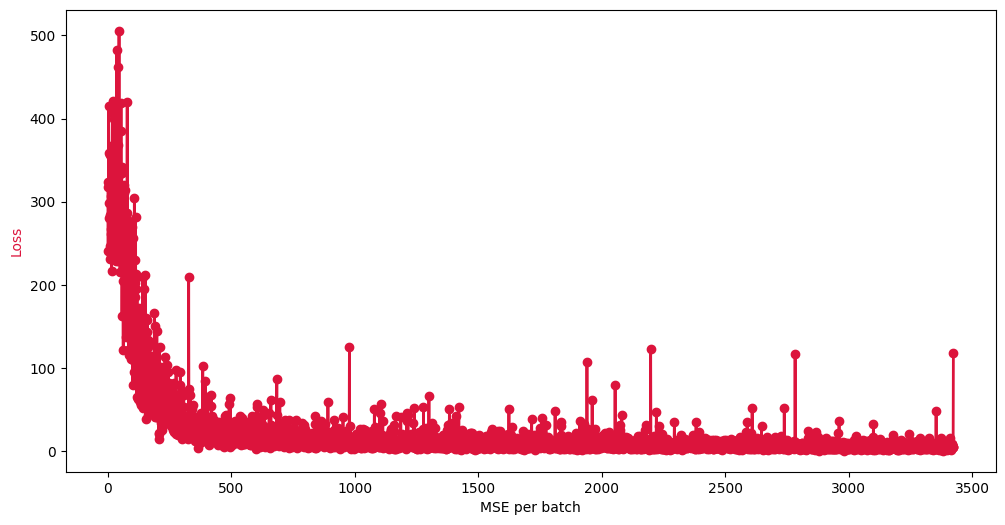

In [14]:
batches = list(range(len(losses)))

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot the Loss ---
color_mse = 'crimson'
ax1.set_xlabel('MSE per batch')
ax1.set_ylabel('Loss', color=color_mse)
line = ax1.plot(batches, losses, color=color_mse, marker='o', linewidth=2, label='Loss(MSE)')

In [15]:
model.eval() # Set to evaluation mode
val_loss = 0.0
total_error = 0.0

with torch.no_grad(): # Disable gradient calculation
    for images, tabular, labels in val_loader:
        # Move to NPU
        images = images.to(device)
        tabular = tabular.to(device)
        labels = labels.to(device).float()

        # Forward pass ONLY
        outputs = model(images, tabular)
        
        # Calculate Loss
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        
        # Calculate MAE (Mean Absolute Error) 
        # This tells you how many 'stages' off you are on average
        total_error += torch.abs(outputs - labels).sum().item()

avg_val_loss = val_loss / len(val_loader)
avg_mae = total_error / len(val_ds)

print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Mean Absolute Error: {avg_mae:.2f} days")

Validation Loss: 6.1979
Mean Absolute Error: 1.45 days


In [16]:
day_results = []

for stage in range(0, 40):
    # 1. Filter the dataframe for this specific stage
    stage_df = df_val[df_val['delta_days'] == stage]
    
    # 2. Initialize a temporary dataset and loader for just this stage
    temp_ds = MyDataset(
        dataframe=stage_df,
        img_dir=PHOTO_VAL_PATH,
        transform=pipeline.transform
    )
    temp_loader = DataLoader(temp_ds, batch_size=16, shuffle=False, num_workers=0)
    
    stage_loss = 0.0
    stage_mae_sum = 0.0
    
    model.eval()
    with torch.no_grad():
        for images, tabular, labels in temp_loader: # Using temp_loader here!
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device).float()
            
            outputs = model(images, tabular)
            loss = criterion(outputs, labels)
            
            stage_loss += loss.item() * images.size(0)
            stage_mae_sum += torch.abs(outputs - labels).sum().item()
    
    # 3. Calculate actual Means
    total_samples = len(temp_ds)
    avg_loss = stage_loss / total_samples
    avg_mae = stage_mae_sum / total_samples
    
    print(f"--- Stage {stage} (n={total_samples}) ---")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Mean Absolute Error: {avg_mae:.2f} days\n")
    day_results.append({
        'total_samples': total_samples,
        'avg_loss': avg_loss,
        'avg_mae': avg_mae
    })

--- Stage 0 (n=32) ---
Average Loss: 16.1788
Mean Absolute Error: 2.81 days

--- Stage 1 (n=28) ---
Average Loss: 1.1078
Mean Absolute Error: 0.95 days

--- Stage 2 (n=26) ---
Average Loss: 0.1678
Mean Absolute Error: 0.34 days

--- Stage 3 (n=28) ---
Average Loss: 5.6623
Mean Absolute Error: 1.45 days

--- Stage 4 (n=59) ---
Average Loss: 1.8926
Mean Absolute Error: 1.18 days

--- Stage 5 (n=56) ---
Average Loss: 2.6732
Mean Absolute Error: 1.38 days

--- Stage 6 (n=38) ---
Average Loss: 2.6268
Mean Absolute Error: 1.19 days

--- Stage 7 (n=49) ---
Average Loss: 1.1460
Mean Absolute Error: 0.82 days

--- Stage 8 (n=40) ---
Average Loss: 1.2447
Mean Absolute Error: 0.84 days

--- Stage 9 (n=49) ---
Average Loss: 1.6898
Mean Absolute Error: 1.03 days

--- Stage 10 (n=65) ---
Average Loss: 1.5095
Mean Absolute Error: 0.94 days

--- Stage 11 (n=50) ---
Average Loss: 1.1335
Mean Absolute Error: 0.85 days

--- Stage 12 (n=39) ---
Average Loss: 0.7158
Mean Absolute Error: 0.67 days

--- Stag

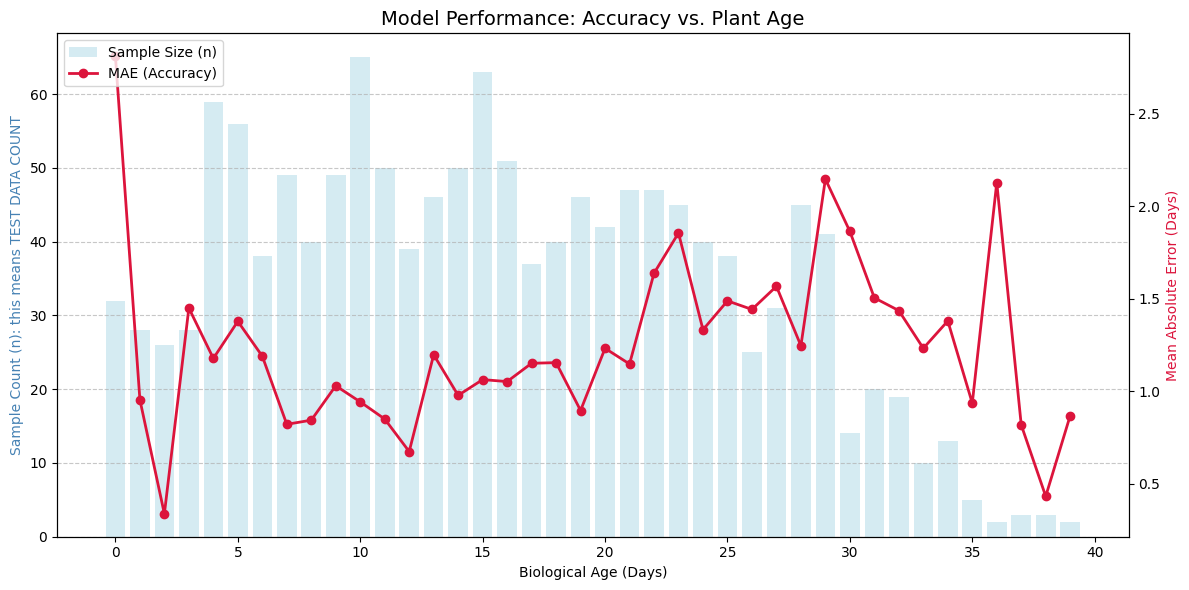

In [17]:
# Prepare the data
days = list(range(len(day_results)))
maes = [res['avg_mae'] for res in day_results]
counts = [res['total_samples'] for res in day_results]

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot the Sample Size (Bars) ---
color_bars = 'lightblue'
ax1.set_xlabel('Biological Age (Days)')
ax1.set_ylabel('Sample Count (n): this means TEST DATA COUNT', color='steelblue')
bars = ax1.bar(days, counts, color=color_bars, alpha=0.5, label='Sample Size (n)')

# --- Plot the MAE (Line) ---
ax2 = ax1.twinx() # Create second y-axis
color_mae = 'crimson'
ax2.set_ylabel('Mean Absolute Error (Days)', color=color_mae)
line = ax2.plot(days, maes, color=color_mae, marker='o', linewidth=2, label='MAE (Accuracy)')

# --- Final Touches ---
plt.title('Model Performance: Accuracy vs. Plant Age', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [18]:
random_index = random.randint(0, len(df_val))
sample_row = df_val[random_index:random_index+1]
real_delta_days = sample_row['delta_days'][random_index]

print(sample_row)
print(f"delta_days(label): {real_delta_days}")

sample_data = MyDataset(
    dataframe=sample_row,
    img_dir=PHOTO_VAL_PATH,
    transform=pipeline.val_transform
)
sample_loader = DataLoader(sample_data, batch_size=1, shuffle=False, num_workers=0)

                  file_name        crops_id  growth             captured kind  \
1309  C30_L01_03_001_487828  C30_L01_03_001       2  2021-10-29 00:16:24  로메인   

          temp     humid       co2     light  hyd_temp  hyd_ec  hyd_ph  \
1309  0.968927  0.614139  1.950149  1.810734      23.7    0.16     6.5   

      stem_area  leaf_area  delta_days  
1309  -0.051905   1.011564          21  
delta_days(label): 21


In [19]:
def plot_image(image, mode="torch"):
    if mode == "torch":
        img_tensor = image[0].cpu()
    elif mode == "raw":
        img_tensor = pipeline.val_transform(image).cpu()
    
    # 2. Permute to Matplotlib format (H, W, C)
    # This turns (3, 512, 512) -> (512, 512, 3)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    
    # 3. Denormalize
    # Now that shape is (512, 512, 3), these (3,) arrays broadcast perfectly!
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # 4. Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img_np)
    plt.title(f"Sample (Mode: {mode})", fontsize=14, color='green')
    plt.axis('off')
    plt.show()

In [20]:
#img = Image.open(PHOTO_VAL_PATH / f"{sample_row['file_name'][random_index]}.jpg").convert('RGB')
#plot_image(img, "raw")

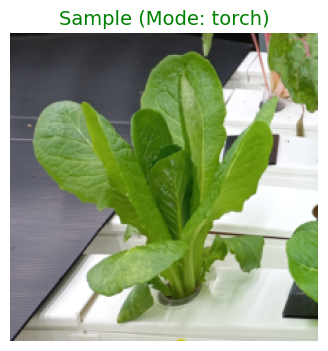

Model prdicted with loss(MSE), 0.20665886998176575 
Predicted: 20.55(days) Real: 21(days)


In [21]:
model.eval() #just in case...

with torch.no_grad():
    for images, tabular, labels in sample_loader: # this will run only once, so don't worrry
        #there should be multiple images here normally, but there is only one of them.
        #well, look at the settings above...
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device).float()

        plot_image(images)
        
        outputs = model(images, tabular)
        loss = criterion(outputs, labels) # this is MSE, see the code above

        raw_prediction = outputs.item()
        print(f"Model prdicted with loss(MSE), {loss} \nPredicted: {raw_prediction:.2f}(days) Real: {real_delta_days}(days)")